This notebook trains Ridge Regression and Random Forest models to predict grid carbon intensity across multiple forecast horizons (1h, 6h, 24h).


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import shap
import warnings
warnings.filterwarnings('ignore')

Load the dataset, one-hot encode regions, and create target variables:

In [4]:
data_path = '/Users/alex/Documents/GitHub/PowerNap/full_dataset_featured.csv'
df = pd.read_csv(data_path)
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values(['region', 'datetime']).reset_index(drop=True)

df_encoded = pd.get_dummies(df, columns=['region'], prefix='region', drop_first=False)
region_cols = [col for col in df_encoded.columns if col.startswith('region_')]

horizons = [1, 6, 24]
for k in horizons:
    df_encoded[f'target_{k}h'] = df_encoded.groupby(df['region'])['carbon_intensity'].shift(-k)

target_cols = [f'target_{k}h' for k in horizons]
df_final = df_encoded.dropna(subset=target_cols).reset_index(drop=True)

print(f'Original shape: {df.shape}')
print(f'Final shape after encoding & shifting: {df_final.shape}')
display(df_final[['datetime', 'carbon_intensity'] + target_cols + region_cols].head())

Original shape: (34944, 22)
Final shape after encoding & shifting: (34848, 28)


,datetime,carbon_intensity,target_1h,target_6h,target_24h,region_california,region_illinois,region_texas,region_virginia
0,2023-01-02 00:00:00,189.75,207.79,225.27,256.64,True,False,False,False
1,2023-01-02 01:00:00,207.79,213.71,228.60,252.97,True,False,False,False
2,2023-01-02 02:00:00,213.71,214.20,247.55,249.97,True,False,False,False
3,2023-01-02 03:00:00,214.20,216.54,254.81,246.11,True,False,False,False
4,2023-01-02 04:00:00,216.54,220.28,258.92,239.29,True,False,False,False


train/test split:

In [5]:
base_features = [
    "temp_c", "wind_speed", "cloud_cover", "solar_radiation",
    "carbon_intensity_lag_1", "carbon_intensity_lag_2",
    "carbon_intensity_lag_3", "carbon_intensity_lag_24",
    "hour_sin", "hour_cos",
    "day_of_week_sin", "day_of_week_cos",
    "month_sin", "month_cos",
    "cfe_pct", "re_pct"
]
features = base_features + region_cols

X = df_final[features]
y = df_final[target_cols]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=999)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Testing set:  {X_test.shape[0]} samples')

Training set: 27878 samples
Testing set:  6970 samples


Ridge Regression (linear) and Random Forest (nonlinear) models:

In [6]:
results = []

def get_metrics(y_true, y_pred, horizon, model, region='Overall'):
    return {
        'Horizon': f'{horizon}h',
        'Model': model,
        'Region': region,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }

for k in horizons:
    target = f'target_{k}h'
    y_tr, y_te = y_train[target], y_test[target]
    
    
    ridge = make_pipeline(StandardScaler(), Ridge())
    ridge.fit(X_train, y_tr)
    ridge_preds = ridge.predict(X_test)
    results.append(get_metrics(y_te, ridge_preds, k, 'Ridge'))
    
    for r_col in region_cols:
        mask = X_test[r_col] == 1
        r_name = r_col.replace('region_', '')
        results.append(get_metrics(y_te[mask], ridge_preds[mask], k, 'Ridge', r_name))
    
    rf = RandomForestRegressor(n_estimators=50, max_depth=8, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_tr)
    rf_preds = rf.predict(X_test)
    results.append(get_metrics(y_te, rf_preds, k, 'Random Forest'))

    for r_col in region_cols:
        mask = X_test[r_col] == 1
        r_name = r_col.replace('region_', '')
        results.append(get_metrics(y_te[mask], rf_preds[mask], k, 'Random Forest', r_name))

results_df = pd.DataFrame(results)
display(results_df.sort_values(['MAE']))

,Horizon,Model,Region,MAE,RMSE,R2
9,1h,Random Forest,virginia,6.310015,8.060298,0.933867
6,1h,Random Forest,california,8.267326,12.171080,0.962617
4,1h,Ridge,virginia,8.318724,10.282413,0.892377
5,1h,Random Forest,Overall,10.377468,14.687926,0.979672
7,1h,Random Forest,illinois,10.814578,13.874509,0.945943
19,6h,Random Forest,virginia,11.253215,14.188040,0.793692
0,1h,Ridge,Overall,13.213381,18.015342,0.969418
29,24h,Random Forest,virginia,13.260259,16.889693,0.697144
1,1h,Ridge,california,13.306023,19.484142,0.904196
2,1h,Ridge,illinois,13.764159,16.989805,0.918943


Comparing the MAE of Ridge vs Random Forest across regions for the furthest horizon (24h):

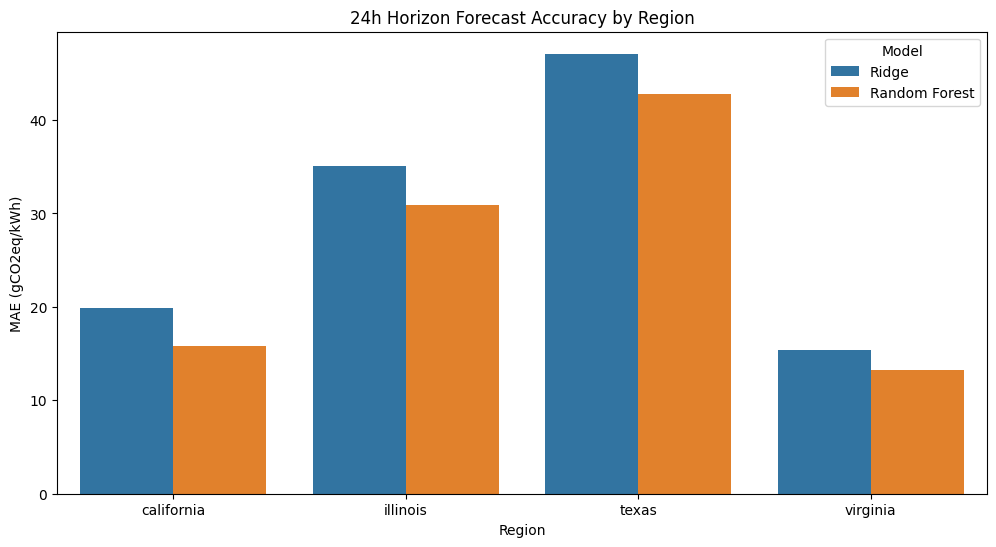

In [7]:
plt.figure(figsize=(12, 6))
viz_df = results_df[(results_df['Horizon'] == '24h') & (results_df['Region'] != 'Overall')]
sns.barplot(data=viz_df, x='Region', y='MAE', hue='Model')
plt.title('24h Horizon Forecast Accuracy by Region')
plt.ylabel('MAE (gCO2eq/kWh)')
plt.show()

Comparing the MAE of Ridge vs Random Forest across regions across all horizons:

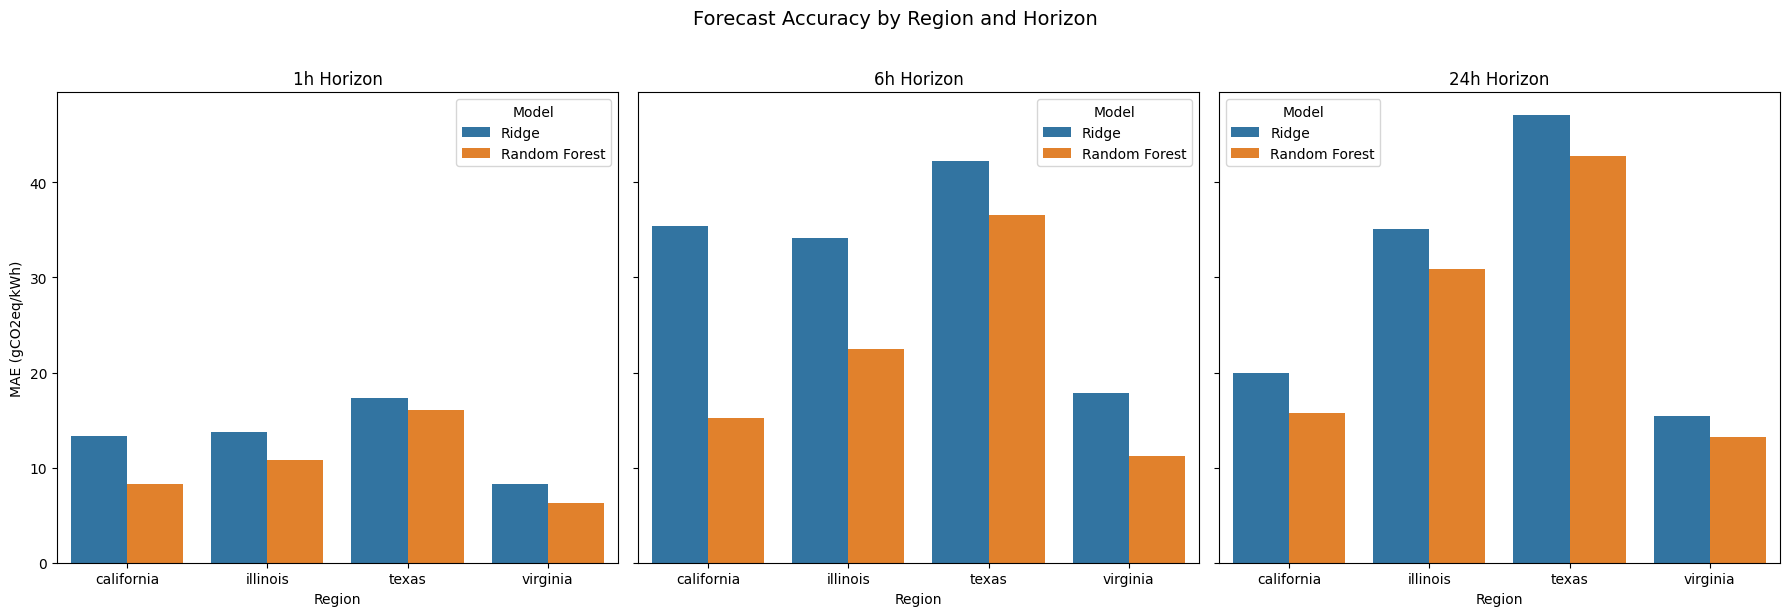

In [8]:
horizons = results_df['Horizon'].unique()
fig, axes = plt.subplots(1, len(horizons), figsize=(6 * len(horizons), 6), sharey=True)

for ax, horizon in zip(axes, horizons):
    viz_df = results_df[(results_df['Horizon'] == horizon) & (results_df['Region'] != 'Overall')]
    sns.barplot(data=viz_df, x='Region', y='MAE', hue='Model', ax=ax)
    ax.set_title(f'{horizon} Horizon')
    ax.set_ylabel('MAE (gCO2eq/kWh)' if ax == axes[0] else '')
    ax.set_xlabel('Region')

plt.suptitle('Forecast Accuracy by Region and Horizon', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

Feature Importance with SHAP:

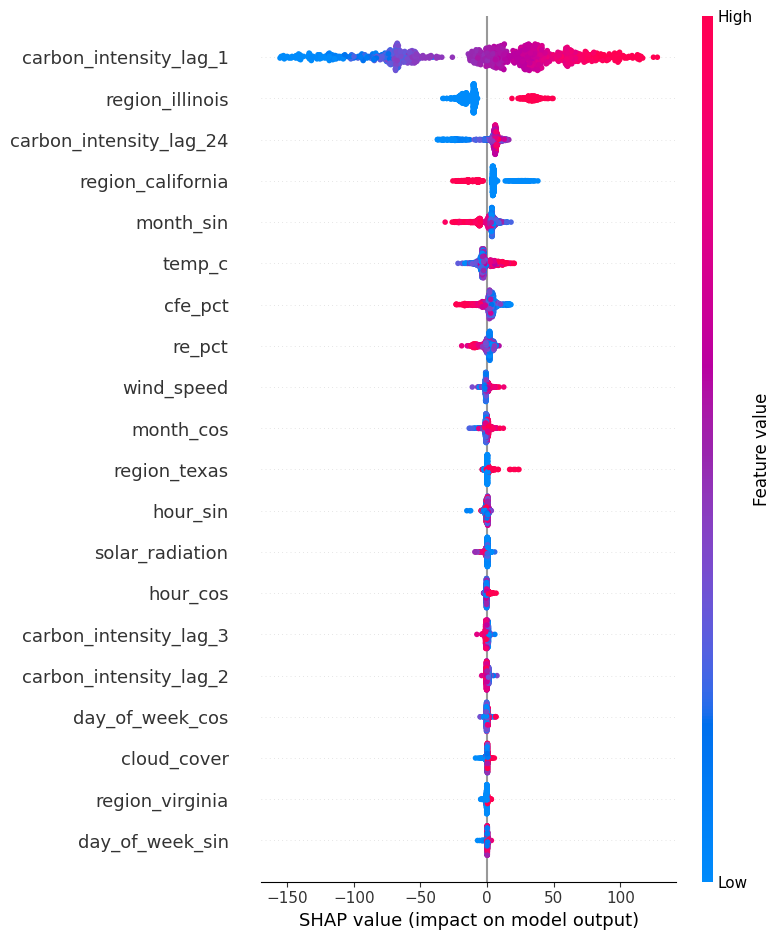

In [12]:
explainer = shap.TreeExplainer(rf)
sample_X = X_test.sample(min(1000, len(X_test)), random_state=42)
shap_values = explainer.shap_values(sample_X)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, sample_X)